<a href="https://colab.research.google.com/github/HinnaNayab/DeepLearning/blob/Applied-AI/Tutorial_5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images = train_images/255.0
test_images = test_images/255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse','ship','truck']


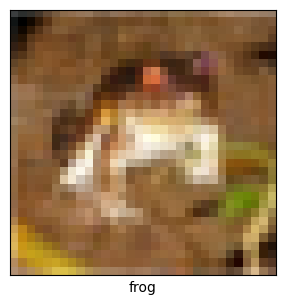

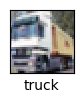

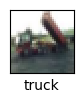

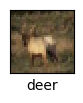

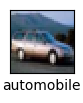

In [ ]:
plt.figure(figsize=(10,20))
for i in range(5):
  plt.subplot(5,1,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i])
  plt.xlabel(class_names[train_labels[i][0]])
  plt.show()


In [11]:
model = models.Sequential([

    # First Convolution Layer
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # First Max Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Second Convolution Layer
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Second Max Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Convert feature maps into a single vector
    layers.Flatten(),
    # Fully connected layer
    layers.Dense(128, activation='relu'),
    # Output layer: 10 classes
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4894 - loss: 1.4333 - val_accuracy: 0.5871 - val_loss: 1.1636
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6188 - loss: 1.0826 - val_accuracy: 0.6405 - val_loss: 1.0314
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6654 - loss: 0.9557 - val_accuracy: 0.6592 - val_loss: 0.9765
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6987 - loss: 0.8550 - val_accuracy: 0.6721 - val_loss: 0.9623
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7295 - loss: 0.7742 - val_accuracy: 0.6783 - val_loss: 0.9527
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7565 - loss: 0.7032 - val_accuracy: 0.6961 - val_loss: 0.9085
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.7764 - loss: 0.6397 - val_accuracy: 0.6871 - val_loss: 0.9301
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 42ms/step - accuracy: 0.7985 -

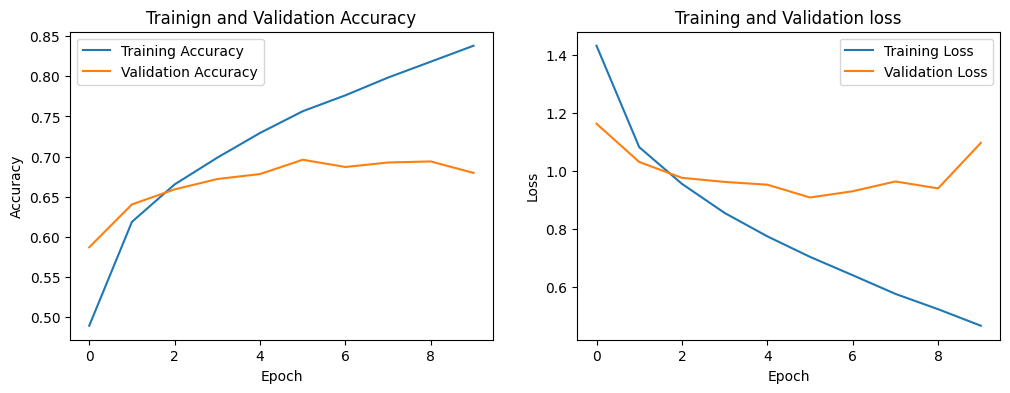

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot (1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Trainign and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot  training and validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [20]:
predictions = model.predict(test_images[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [23]:
def plot_image(i, predictions_array, true_label, img, class_names):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(img)
  predicted_label = np.argmax(predictions_array)

  color = 'blue' if predicted_label == true_label else 'red'
  plt.xlabel(f"Predicted:{class_names[predicted_label]} (True:{class_names[true_label[0]]})", color= color)
  plt.figure(figsize=(5,10))

  for i in range(5):
    plt.subplot(5,1,i+1)
    plot_image(i, predictions, test_labels, test_images, class_names)
    plt.tight_layout()
    plt.show()